<a href="https://colab.research.google.com/github/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Посилання на файл `process_bank_churn.py`

https://github.com/veapasichnyk/HomeWorksDataLovesAcademy/blob/main/process_bank_churn.py

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.listdir()

['.config',
 '__pycache__',
 '.ipynb_checkpoints',
 'submission.csv',
 'train.csv',
 'test.csv',
 'process_bank_churn.py',
 'sample_submission.csv',
 'sample_data']

In [3]:
%load_ext autoreload
%autoreload 2

from process_bank_churn import (preprocess_data, preprocess_new_data)

In [4]:
df = pd.read_csv("train.csv")
X_train, y_train, X_val, y_val, input_cols, scaler, encoder, feature_names = preprocess_data(df)

In [5]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score

In [7]:
#Створення моделі
model = DecisionTreeClassifier(random_state=42)

In [8]:
#Тренування моделі
%%time
model.fit(X_train, y_train)

CPU times: user 89.2 ms, sys: 107 µs, total: 89.4 ms
Wall time: 148 ms


DecisionTreeClassifier(random_state=42)

In [9]:
#Прогнози й обчислення AUC
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"AUC на тренувальних даних: {train_auc:.4f}")
print(f"AUC на валідаційних даних: {val_auc:.4f}")

AUC на тренувальних даних: 1.0000
AUC на валідаційних даних: 0.7700


In [10]:
#Глибина дерева
print(f"Глибина дерева: {model.get_depth()}")

Глибина дерева: 26


In [11]:
# Побудова дерева до глибини 2
model_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)

In [12]:
%%time
model_depth2.fit(X_train, y_train)

CPU times: user 17.7 ms, sys: 0 ns, total: 17.7 ms
Wall time: 31.9 ms


DecisionTreeClassifier(max_depth=2, random_state=42)

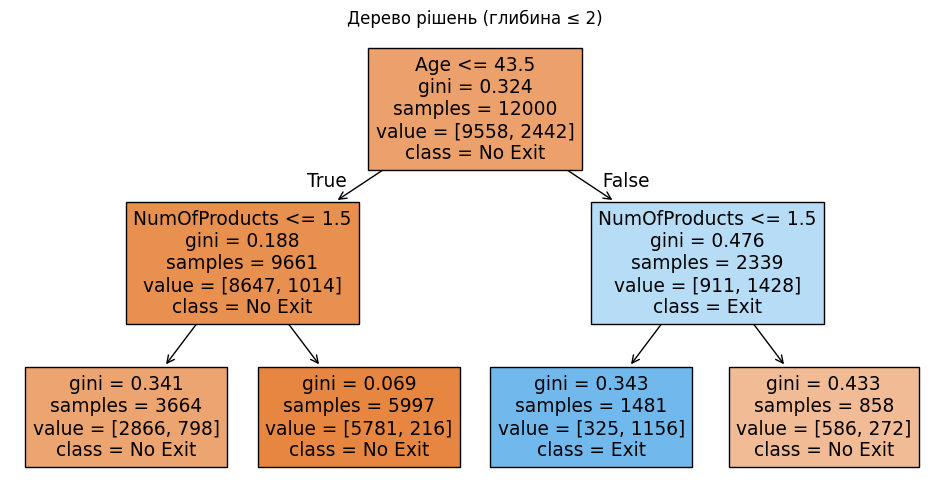

In [13]:
# Візуалізація дерева
plt.figure(figsize=(12, 6))
plot_tree(model_depth2, feature_names=input_cols, class_names=["No Exit", "Exit"], filled=True)
plt.title("Дерево рішень (глибина ≤ 2)")
plt.show()

In [14]:
# Ознаки, що використовуються
used_features = set(model_depth2.tree_.feature)
used_features.discard(-2)  # -2 означає, що вузол — лист, без поділу
feature_names_used = [input_cols[i] for i in used_features]

print("Найвпливові ознаки (глибина ≤ 2):")
for feat in feature_names_used:
    print(f"- {feat}")

Найвпливові ознаки (глибина ≤ 2):
- Age
- NumOfProducts


**Спостереження**

Що видно з дерева:

- Клієнти віком ≤ 43.5 років і з ≤ 1.5 продуктами (велика група: 3664 клієнти, з яких 798 пішли). gini - коефіцієнт низький, тобто модель впевнена у прогнозі.

- Клієнти > 43.5 років і з ≤ 1.5 продуктами: набагато більше виходів (клас = Exit) і тут ми бачимо основну групу ризику.

Отже, молоді клієнти з кількома продуктами - найстабільніші. А старші клієнти з малою активністю - схильні до виходу.

In [15]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [16]:
# Сортуємо за спаданням важливості
importance_df = importance_df.sort_values(by='importance', ascending=False)

In [17]:
# Виводимо топ-10 ознак
top_10 = importance_df.head(10)
print(top_10)

              feature  importance
1                 Age    0.356789
4       NumOfProducts    0.168379
7     EstimatedSalary    0.123635
0         CreditScore    0.123283
3             Balance    0.079192
2              Tenure    0.052899
6      IsActiveMember    0.032688
11      Gender_Female    0.014908
9   Geography_Germany    0.014725
5           HasCrCard    0.012957


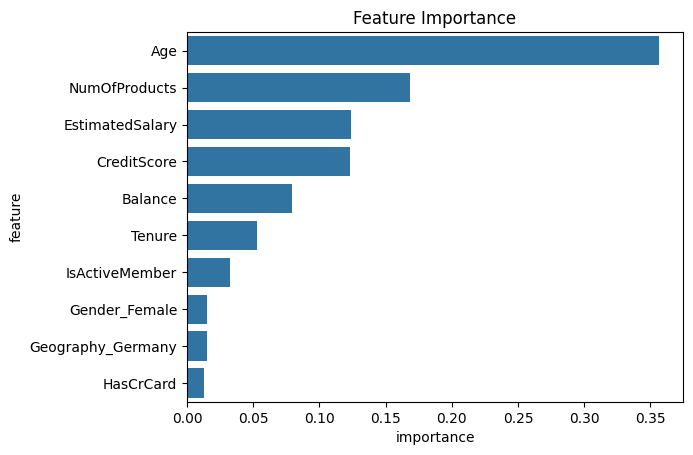

In [18]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [19]:
model = DecisionTreeClassifier(max_depth=3, max_leaf_nodes=10, random_state=42)

In [20]:
%%time
model.fit(X_train, y_train)

CPU times: user 24 ms, sys: 0 ns, total: 24 ms
Wall time: 24 ms


DecisionTreeClassifier(max_depth=3, max_leaf_nodes=10, random_state=42)

In [21]:
#Прогнози й обчислення AUC
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"AUC на тренувальних даних: {train_auc:.4f}")
print(f"AUC на валідаційних даних: {val_auc:.4f}")

AUC на тренувальних даних: 0.8972
AUC на валідаційних даних: 0.8911


**Cпостереження**

Значення AUC на тренувальних даних: 0.8972 та AUC на валідаційних даних: 0.8911 свідчать, що модель досить добре генралізується, оскільки показники AUC майже однакові на тренувальній і валідаційній вибірці. І малі відмінності між AUC на тренувальних і валідаційних даних означають, що модель не переобучена (overfitting) і не недонавчена (underfitting). Досить хороший результат як на метод "тика" :)

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [22]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    train_error = 1 - model.score(X_train, y_train)
    val_error = 1 - model.score(X_val, y_val)
    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [23]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: user 1.35 s, sys: 4.34 ms, total: 1.36 s
Wall time: 2.22 s


In [24]:
errors_df.style.background_gradient(subset='Validation Error', cmap='Blues_r')

,Max Depth,Training Error,Validation Error
0,1,0.160417,0.177333
1,2,0.134250,0.139000
2,3,0.118500,0.125333
3,4,0.112750,0.118000
4,5,0.104750,0.112667
5,6,0.095917,0.109000
6,7,0.092250,0.110333
7,8,0.081833,0.109667
8,9,0.073667,0.114667
9,10,0.064167,0.117333


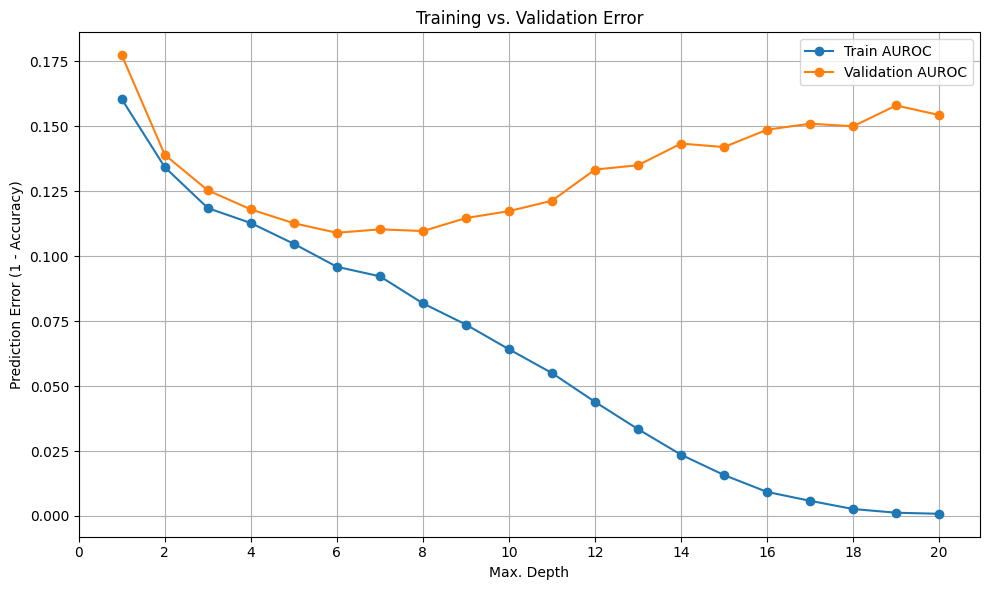

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(errors_df['Max Depth'], errors_df['Training Error'], label='Train AUROC', marker='o')
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'], label='Validation AUROC', marker='o')
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend()
plt.grid(True)
plt.tight_layout()

**Спостереження**

Отже, найкраще отримане значення для `max_depth = 6`.

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [26]:
# Побудова дерева до глибини 6
model = DecisionTreeClassifier(max_depth=6, random_state=42)

In [27]:
#Тренування моделі
%%time
model.fit(X_train, y_train)

CPU times: user 44.8 ms, sys: 5 µs, total: 44.8 ms
Wall time: 45.9 ms


DecisionTreeClassifier(max_depth=6, random_state=42)

In [28]:
#Завантажуємо тестові дані
test_data = pd.read_csv('test.csv')

In [29]:
X_test_processed = preprocess_new_data(test_data, input_cols, scaler, encoder)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OneHotEncoder was fitted without feature names
  warnings.warn(


In [30]:
#Передбачення
predictions = model.predict_proba(X_test_processed)[:, 1]

In [31]:
#Зчитати шаблон для сабміту
submission_df = pd.read_csv("sample_submission.csv")

In [32]:
#Заповнити колонку Exited у шаблоні
submission_df["Exited"] = predictions

In [33]:
submission_df.head()

,id,Exited
0,15000,0.171206
1,15001,0.039422
2,15002,0.015789
3,15003,0.679612
4,15004,0.039422


In [34]:
submission_df.to_csv("submission.csv", index=False)

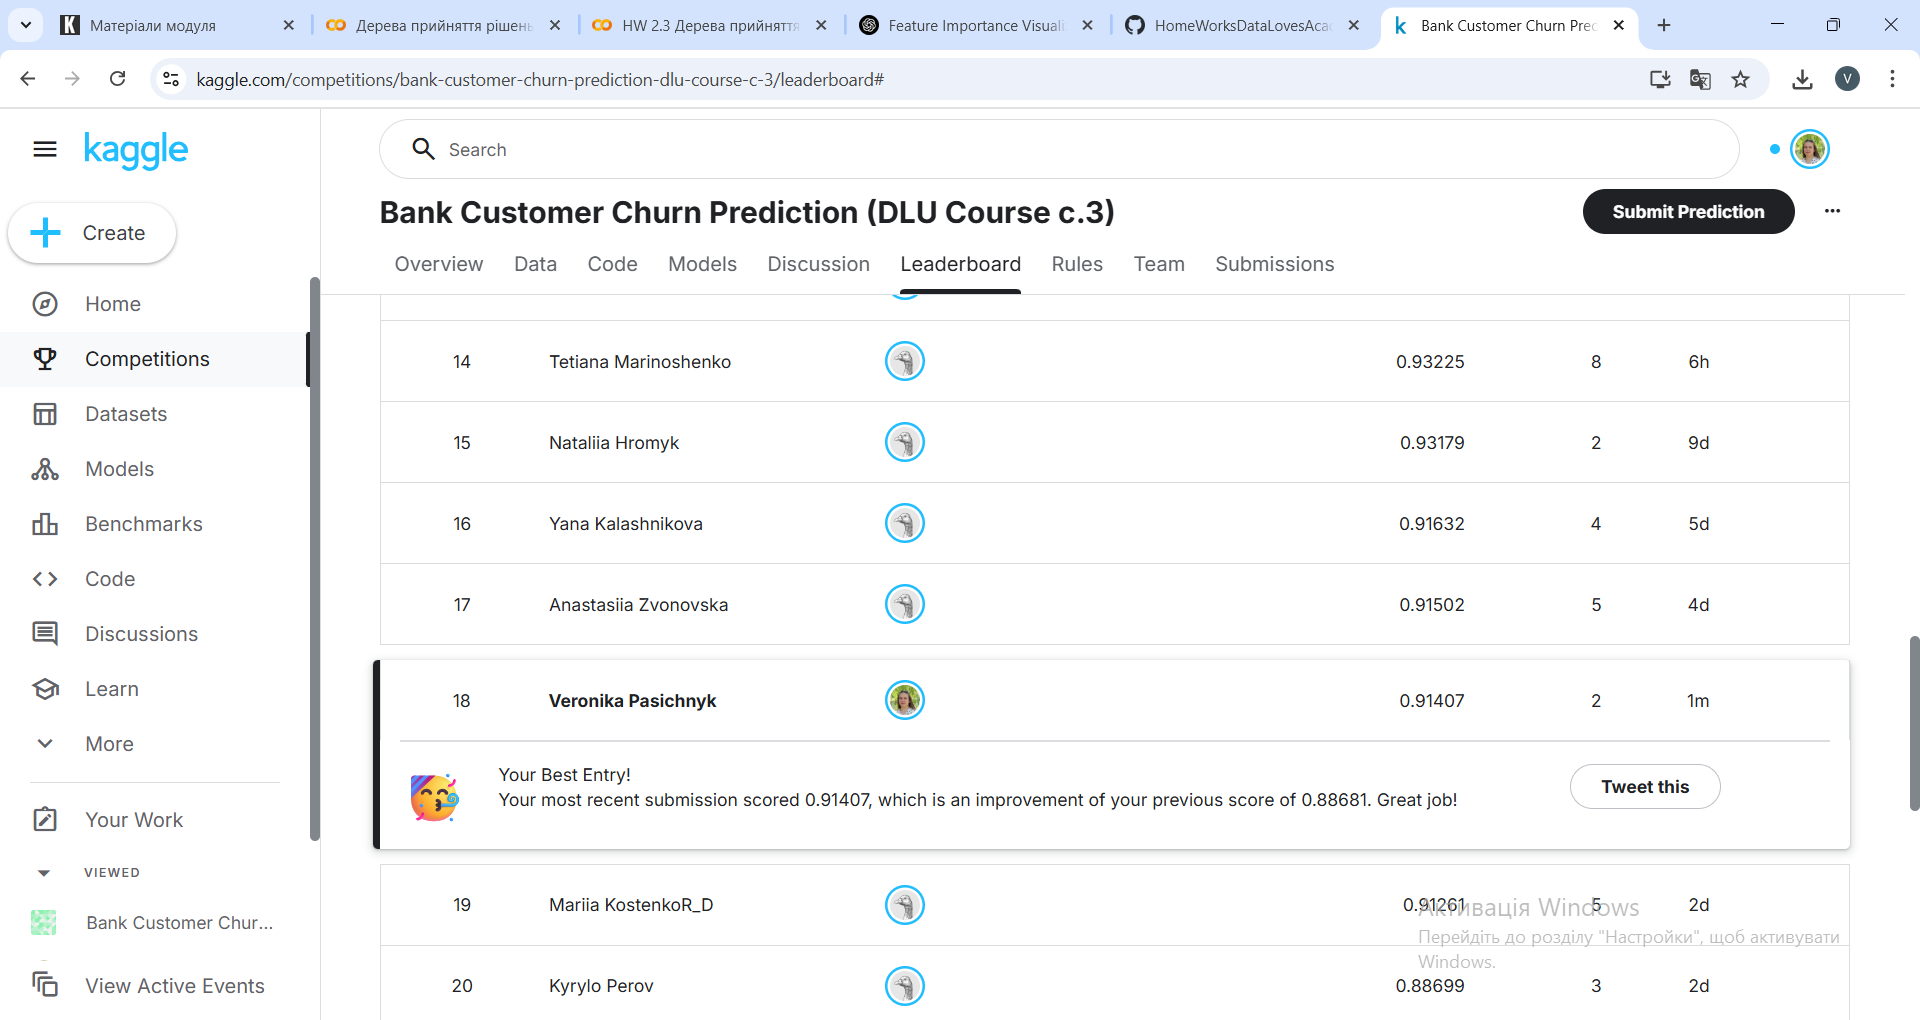